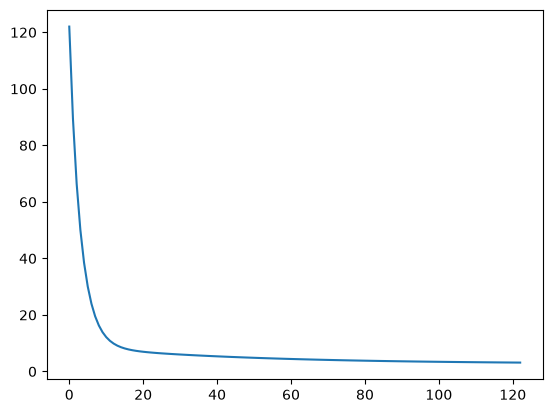

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#Read the dataset
train = np.loadtxt('Iris.csv', delimiter=',', skiprows=1, usecols = (1, 2, 3, 4))
SepalLengthCm = train[:, 0]
SepalWidthCm = train[:, 1]
PetalLengthCm = train[:, 2]
PetalWidthCm = train[:, 3]

#Standardization
def standizatize(x):
    return (x - x.mean())/ (x.std())

SepalLengthCm_standardized = standizatize(SepalLengthCm)
SepalWidthCm_standardized = standizatize(SepalWidthCm)
PetalLengthCm_standardized = standizatize(PetalLengthCm)

def to_matrix(x):
    return np.vstack([np.ones(x.shape[0]), SepalLengthCm_standardized, SepalWidthCm_standardized, PetalLengthCm_standardized]).T

X = to_matrix(train)

#Parameter initialization
theta = np.random.rand(4)

#Prediction function
def f(x):
    return np.dot(x, theta)

#Objective function
def E(x, y):
    return 0.5 * np.sum((y - f(x)) ** 2)

#Learning rate
ETA = 1e-3

#The record of errors
errors = []

#误差的差值
diff = 1

errors.append(E(X, PetalWidthCm))
while diff > 1e-2:
    theta = theta - ETA * np.dot(f(X) - PetalWidthCm, X)
    errors.append(E(X,PetalWidthCm))
    diff = errors[-2] - errors[-1]

x = np.arange(len(errors)) 
plt.plot(x, errors)
plt.show() 